In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\Vivek\Downloads\seaice.csv\seaice.csv")

In [24]:
df.head()

,Year,Month,Day,Extent,hemisphere
0,1978,10,26,10.231,north
1,1978,10,28,10.420,north
2,1978,10,30,10.557,north
3,1978,11,1,10.670,north
4,1978,11,3,10.777,north


In [25]:
df.describe()

,Year,Month,Day,Extent
count,26354.000000,26354.000000,26354.000000,26354.000000
mean,2000.591941,6.507399,15.740685,11.494986
std,10.896821,3.451938,8.801607,4.611734
min,1978.000000,1.000000,1.000000,2.080000
25%,1992.000000,4.000000,8.000000,7.601000
50%,2001.000000,7.000000,16.000000,12.217000
75%,2010.000000,10.000000,23.000000,15.114000
max,2019.000000,12.000000,31.000000,20.201000


In [26]:
df.describe(include="all")

,Year,Month,Day,Extent,hemisphere
count,26354.000000,26354.000000,26354.000000,26354.000000,26354
unique,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,north
freq,NaN,NaN,NaN,NaN,13177
mean,2000.591941,6.507399,15.740685,11.494986,NaN
std,10.896821,3.451938,8.801607,4.611734,NaN
min,1978.000000,1.000000,1.000000,2.080000,NaN
25%,1992.000000,4.000000,8.000000,7.601000,NaN
50%,2001.000000,7.000000,16.000000,12.217000,NaN
75%,2010.000000,10.000000,23.000000,15.114000,NaN


In [ ]:
for col in df.columns:
    print(f"{col}:{len(col)}")
    print()

Year:4
 Month:6
 Day:4
     Extent:11
    Missing:11
 Source Data:12
hemisphere:10


In [21]:
df.rename(columns={"     Extent":"Extent","    Missing":"Missing"," Source Data":"Source Data" },inplace=True)

In [23]:
df.drop(["Missing","Source Data"],axis=1, inplace=True)

In [27]:
df[df['hemisphere']=="north"].describe(include="all")

,Year,Month,Day,Extent,hemisphere
count,13177.000000,13177.000000,13177.000000,13177.000000,13177
unique,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,north
freq,NaN,NaN,NaN,NaN,13177
mean,2000.591941,6.507399,15.740685,11.362796,NaN
std,10.897027,3.452003,8.801774,3.259783,NaN
min,1978.000000,1.000000,1.000000,3.340000,NaN
25%,1992.000000,4.000000,8.000000,8.670000,NaN
50%,2001.000000,7.000000,16.000000,12.076000,NaN
75%,2010.000000,10.000000,23.000000,14.236000,NaN


In [28]:
df[df['hemisphere']=="south"].describe(include="all")

,Year,Month,Day,Extent,hemisphere
count,13177.000000,13177.000000,13177.000000,13177.000000,13177
unique,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,south
freq,NaN,NaN,NaN,NaN,13177
mean,2000.591941,6.507399,15.740685,11.627176,NaN
std,10.897027,3.452003,8.801774,5.645942,NaN
min,1978.000000,1.000000,1.000000,2.080000,NaN
25%,1992.000000,4.000000,8.000000,6.004000,NaN
50%,2001.000000,7.000000,16.000000,12.537000,NaN
75%,2010.000000,10.000000,23.000000,17.205000,NaN


# Distribution of Extent

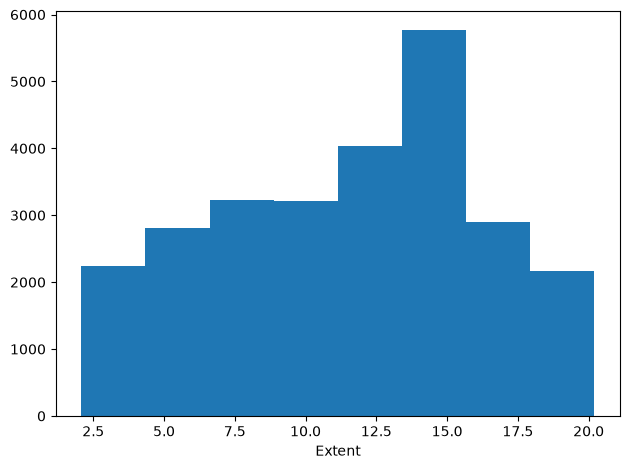

In [36]:
fig, ax = plt.subplots()
ax.hist(df['Extent'],bins =8)
ax.set_xlabel("Extent")
plt.tight_layout()

## Insights
##### Left-skewed

# Year wise average extent of ice

In [37]:
df.columns

Index(['Year', ' Month', ' Day', 'Extent', 'hemisphere'], dtype='str')

In [41]:
yearwise_extent = df.groupby(['Year','hemisphere'])['Extent'].mean()
yearwise_extent

Year  hemisphere
1978  north         12.487000
      south         13.466676
1979  north         12.319560
      south         11.719137
1980  north         12.334148
                      ...    
2017  south         10.748926
2018  north         10.326964
      south         10.937660
2019  north         13.610510
      south          4.876781
Name: Extent, Length: 84, dtype: float64

In [51]:
yearwise_extent_unstack = yearwise_extent.unstack(level = -1)


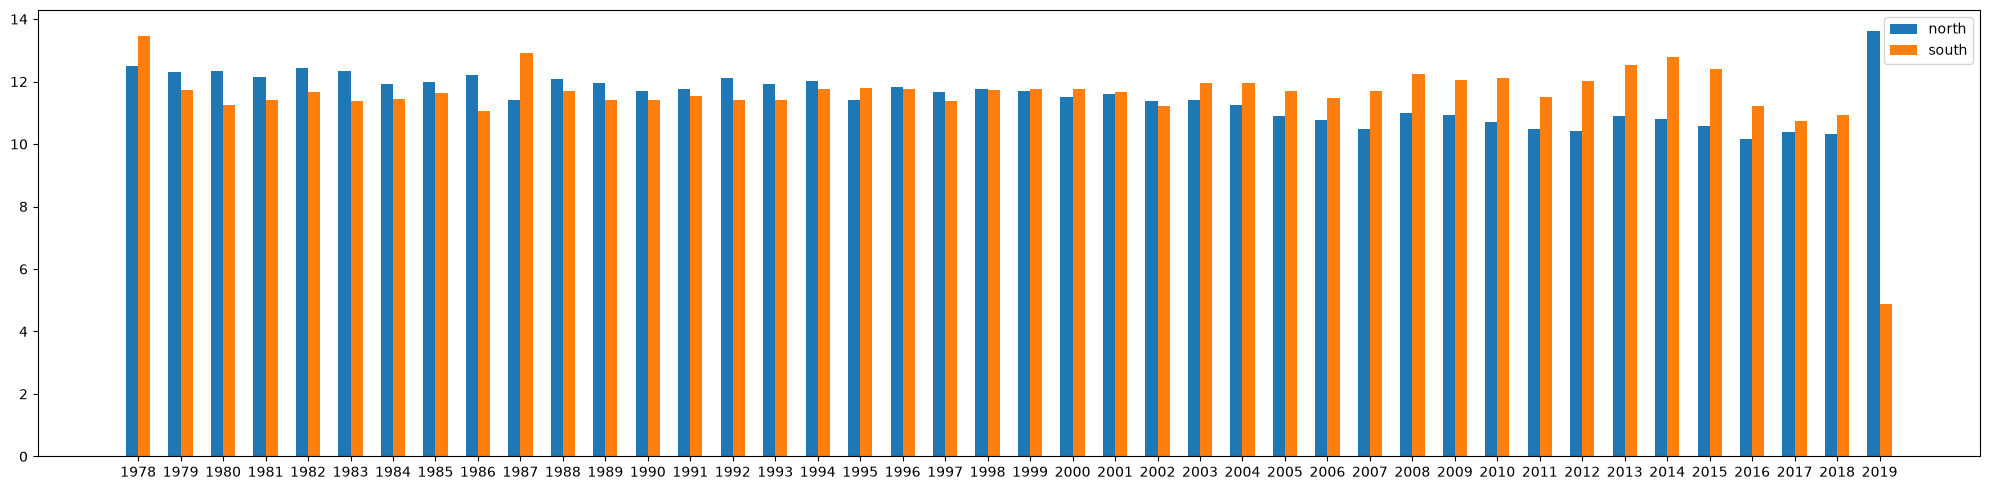

In [57]:
fig, ax = plt.subplots(figsize = (20,5))
ax.grouped_bar(yearwise_extent_unstack.values, tick_labels = yearwise_extent_unstack.index, labels = yearwise_extent_unstack.columns)
ax.legend()
plt.tight_layout()